In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/active_users.csv
/kaggle/input/clean_raw_data_version3_mean_minmax.csv


## Install libraries

In [2]:
!pip install torch-geometric
!pip install optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.2 MB/s eta 0:00:00a 0:00:01


## Read dataset

In [3]:
raw_data = pd.read_csv("/kaggle/input/active_users.csv")
raw_data.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pan

,user_id,course_id,gender,school,enroll_time,comment_count_week1,reply_count_week1,questions_done_week1,attempts_count_week1,correct_answers_week1,...,reply_count_week4,questions_done_week4,attempts_count_week4,correct_answers_week4,total_score_week4,user_watching_time_week4,classification,classification_encoded,school_encoded,course_id_encoded
0,U_1001413,C_735164,0.0,昆明理工大学,2020-11-26 23:40:08,NaN,NaN,156.0,164.0,155.0,...,NaN,NaN,NaN,NaN,NaN,NaN,A,0,476,138
1,U_1001522,C_735164,0.0,昆明理工大学,2020-12-01 11:11:06,NaN,NaN,156.0,156.0,156.0,...,NaN,NaN,NaN,NaN,NaN,NaN,A,0,476,138
2,U_1001694,C_735164,0.0,昆明理工大学,2020-11-18 19:49:32,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,A,0,476,138
3,U_1001697,C_735164,0.0,昆明理工大学,2020-11-28 11:03:45,NaN,NaN,5.0,8.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,A,0,476,138
4,U_1001703,C_735164,0.0,昆明理工大学,2020-10-19 20:57:49,NaN,NaN,NaN,NaN,NaN,...,NaN,108.0,109.0,108.0,130.0,NaN,A,0,476,138


## Import libraries

In [4]:
import networkx as nx
from torch_geometric.data import Data
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

## Create graph with networkX

In [5]:
df = raw_data.copy()

## SCENARIOS 1+2: MLP-ADVERSARIAL (WITHOUT GRAPH STRUCTURE) and GCN-MSE (WITHOUT ADVERSARIAL LEARNING)

Đang đọc dữ liệu từ: -f...
Đọc thành công. Dữ liệu có 16391 dòng và 37 cột.

 BẮT ĐẦU THÍ NGHIỆM (a): GCN-MSE (Không có học đối kháng) 

Bắt đầu huấn luyện mô hình GCN-MSE...
Epoch 20/150, MSE Loss: 0.2465
Epoch 40/150, MSE Loss: 0.1202
Epoch 60/150, MSE Loss: 0.0696
Epoch 80/150, MSE Loss: 0.0423
Epoch 100/150, MSE Loss: 0.0271
Epoch 120/150, MSE Loss: 0.0178
Epoch 140/150, MSE Loss: 0.0126

Bắt đầu điền khuyết dữ liệu...
Kiểm tra ràng buộc sau khi điền khuyết:
Tất cả các ràng buộc đều được thỏa mãn!

Đánh giá hiệu suất điền khuyết:
Epoch 20/150, MSE Loss: 0.2710
Epoch 40/150, MSE Loss: 0.1433
Epoch 60/150, MSE Loss: 0.0893
Epoch 80/150, MSE Loss: 0.0581
Epoch 100/150, MSE Loss: 0.0390
Epoch 120/150, MSE Loss: 0.0269
Epoch 140/150, MSE Loss: 0.0191
Validation MSE for GCN_MSE: 1662.9052


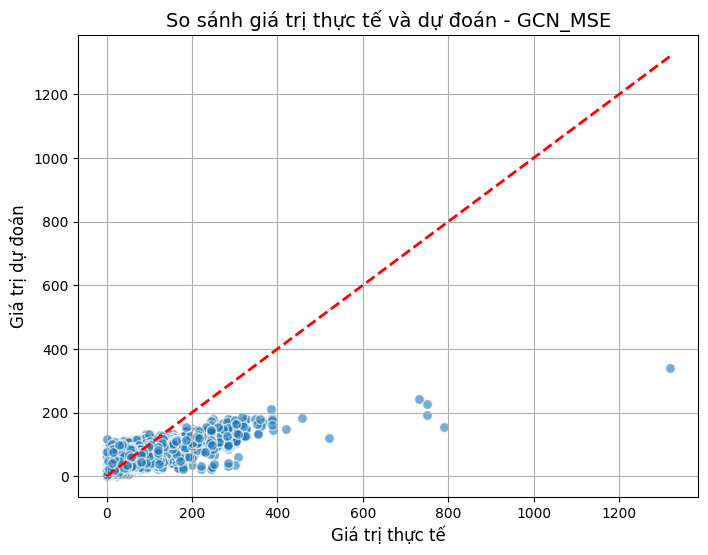


 BẮT ĐẦU THÍ NGHIỆM (b): MLP-Adversarial (Không có cấu trúc đồ thị) 

Bắt đầu huấn luyện mô hình MLP-Adversarial...
Epoch 20/150, Model Loss: 0.0202
Early stopping at epoch 30

Bắt đầu điền khuyết dữ liệu...
Kiểm tra ràng buộc sau khi điền khuyết:
Tất cả các ràng buộc đều được thỏa mãn!

Đánh giá hiệu suất điền khuyết:
Early stopping at epoch 18
Validation MSE for MLP_ADVERSARIAL: 955.6710


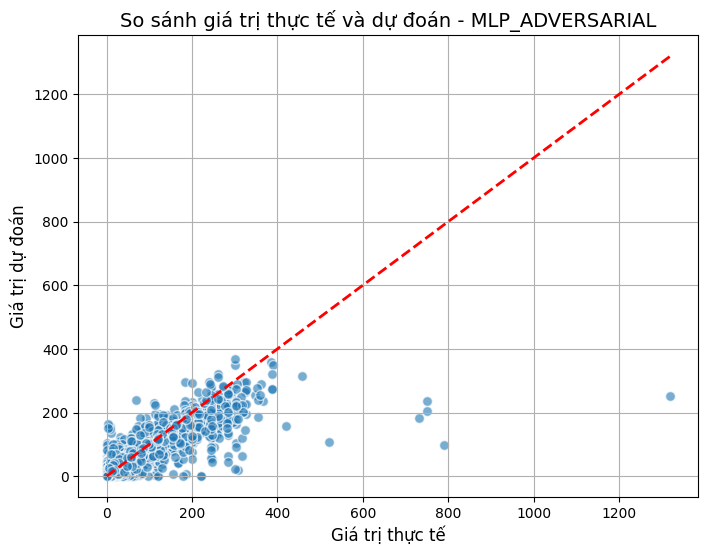


✅ Đã lưu kết quả Thí nghiệm (a) vào: -f
✅ Đã lưu kết quả Thí nghiệm (b) vào: -f

############################################################
              KẾT QUẢ TỔNG HỢP CÁC THÍ NGHIỆM               
############################################################
-> Thí nghiệm (a) - GCN-MSE (Chỉ có Graph): 		 Validation MSE = 1662.9052
-> Thí nghiệm (b) - MLP-Adversarial (Chỉ có Adversarial): 	 Validation MSE = 955.6710

So sánh:
=> Mô hình MLP-Adversarial (chỉ sử dụng học đối kháng) cho kết quả tốt hơn (MSE thấp hơn).
   Điều này cho thấy cơ chế học đối kháng hiệu quả hơn trong việc nắm bắt phân phối dữ liệu.
############################################################


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import time
import re

# Danh sách các cột cần điền khuyết
WEEKLY_COLUMNS = [
    'comment_count_week1', 'reply_count_week1', 'questions_done_week1',
    'attempts_count_week1', 'correct_answers_week1', 'total_score_week1',
    'user_watching_time_week1', 'comment_count_week2', 'reply_count_week2',
    'questions_done_week2', 'attempts_count_week2', 'correct_answers_week2',
    'total_score_week2', 'user_watching_time_week2', 'comment_count_week3',
    'reply_count_week3', 'questions_done_week3', 'attempts_count_week3',
    'correct_answers_week3', 'total_score_week3', 'user_watching_time_week3',
    'comment_count_week4', 'reply_count_week4', 'questions_done_week4',
    'attempts_count_week4', 'correct_answers_week4', 'total_score_week4',
    'user_watching_time_week4'
]

# =====================================================
# PHẦN CHUNG: Các hàm tiện ích dùng cho cả 2 thí nghiệm
# =====================================================

def get_column_patterns():
    patterns = {
        'comment_count': re.compile(r'comment_count_week(\d+)'),
        'reply_count': re.compile(r'reply_count_week(\d+)'),
        'questions_done': re.compile(r'questions_done_week(\d+)'),
        'attempts_count': re.compile(r'attempts_count_week(\d+)'),
        'correct_answers': re.compile(r'correct_answers_week(\d+)'),
        'total_score': re.compile(r'total_score_week(\d+)'),
        'user_watching_time': re.compile(r'user_watching_time_week(\d+)')
    }
    return patterns

def preprocess_data(df):
    df_copy = df.copy()

    if 'enroll_time' in df_copy.columns:
        df_copy['enroll_time'] = pd.to_datetime(df_copy['enroll_time'])
        df_copy['enroll_time_num'] = (df_copy['enroll_time'] - df_copy['enroll_time'].min()).dt.total_seconds()

    feature_cols = [col for col in WEEKLY_COLUMNS if col in df_copy.columns]

    scaler = StandardScaler()
    # Điền khuyết tạm thời bằng giá trị trung bình theo nhóm để chuẩn hóa
    df_copy[feature_cols] = scaler.fit_transform(
        df_copy[feature_cols].fillna(
            df_copy.groupby('classification')[feature_cols].transform('mean')
        )
    )

    return df_copy, feature_cols, scaler

def create_graph(df, feature_cols, k=5, prune_threshold=0.5):
    x = torch.tensor(df[feature_cols].fillna(0).values, dtype=torch.float)
    n = len(df)

    adj = np.zeros((n, n))

    if 'school_encoded' in df.columns and 'course_id_encoded' in df.columns:
        grouped = df.groupby(['school_encoded', 'course_id_encoded']).indices
        for indices in grouped.values():
            indices = list(indices)
            if len(indices) > 1:
                for i in range(len(indices)):
                    for j in range(i+1, len(indices)):
                        adj[indices[i], indices[j]] = 1
                        adj[indices[j], indices[i]] = 1

    if adj.sum() < n:
        base_features = x.numpy()
        is_all_zero = np.all(base_features == 0, axis=0)
        if np.any(is_all_zero):
            base_features = base_features[:, ~is_all_zero]

        if base_features.shape[1] > 0:
            dist_matrix = squareform(pdist(base_features, 'euclidean'))
            dist_std = dist_matrix.std() if dist_matrix.std() > 0 else 1
            sim_matrix = np.exp(-dist_matrix / dist_std)
            sim_matrix[sim_matrix < prune_threshold] = 0

            k = min(k, n-1)
            neighbors = np.argsort(sim_matrix, axis=1)[:, -k:]
            for i in range(n):
                for j in neighbors[i]:
                    if sim_matrix[i, j] > 0:
                        adj[i, j] = 1
                        adj[j, i] = 1

    edge_index = torch.tensor(np.array(np.nonzero(adj)), dtype=torch.long)
    mask = torch.tensor(~np.isnan(df[feature_cols].values), dtype=torch.bool)

    return Data(x=x, edge_index=edge_index), mask

def apply_constraints(df, feature_cols):
    patterns = get_column_patterns()
    df_constrained = df.copy()
    for col in feature_cols:
        for pattern_name, pattern in patterns.items():
            match = pattern.match(col)
            if match:
                week = int(match.group(1))
                if pattern_name in ['comment_count', 'reply_count', 'questions_done', 'total_score', 'user_watching_time', 'attempts_count']:
                    df_constrained[col] = df_constrained[col].clip(lower=0)
                elif pattern_name == 'correct_answers':
                    questions_col = f'questions_done_week{week}'
                    if questions_col in df_constrained.columns:
                        df_constrained[col] = np.minimum(np.maximum(df_constrained[col], 0), df_constrained[questions_col])
    return df_constrained

def check_constraints(df, verbose=True):
    patterns = get_column_patterns()
    violations = 0

    for col in df.columns:
        for pattern_name, pattern in patterns.items():
            match = pattern.match(col)
            if match:
                week = int(match.group(1))
                if pattern_name in ['comment_count', 'reply_count', 'questions_done', 'attempts_count', 'total_score', 'user_watching_time']:
                    neg_count = (df[col] < 0).sum()
                    if neg_count > 0 and verbose:
                        print(f"Vi phạm: {neg_count} giá trị âm trong cột {col}")
                    violations += neg_count
                elif pattern_name == 'correct_answers':
                    questions_col = f'questions_done_week{week}'
                    if questions_col in df.columns:
                        invalid_neg = (df[col] < 0).sum()
                        invalid_high = (df[col] > df[questions_col]).sum()
                        if invalid_neg > 0 and verbose:
                            print(f"Vi phạm: {invalid_neg} giá trị âm trong cột {col}")
                        if invalid_high > 0 and verbose:
                            print(f"Vi phạm: {invalid_high} trường hợp {col} > {questions_col}")
                        violations += (invalid_neg + invalid_high)

    if violations == 0 and verbose:
        print("Tất cả các ràng buộc đều được thỏa mãn!")

    return violations

# =====================================================
# EXPERIMENT (a): GCN-MSE (Without Adversarial Learning)
# =====================================================

class GCNImputerMSE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super(GCNImputerMSE, self).__init__()
        self.dropout = dropout
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.dec_conv1 = GCNConv(hidden_channels, hidden_channels)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_conv2 = GCNConv(hidden_channels, out_channels)
        self.residual = nn.Linear(in_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        h = F.relu(self.bn1(self.conv1(x, edge_index)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.bn2(self.conv2(h, edge_index)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = F.relu(self.dec_bn1(self.dec_conv1(h, edge_index)))
        out = F.dropout(out, p=self.dropout, training=self.training)
        out = self.dec_conv2(out, edge_index)
        out = out + self.residual(x)
        return out

def train_gcn_mse(model, data, mask, original_values, optimizer, epochs=100, early_stop_patience=10):
    model.train()
    losses = []
    best_loss = float('inf')
    patience_counter = 0

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model, data, mask, original_values = model.to(device), data.to(device), mask.to(device), original_values.to(device)

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(data)

        loss = F.mse_loss(output[mask], original_values[mask])

        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if loss.item() < best_loss:
            best_loss = loss.item()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stop_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

        if (epoch+1) % 20 == 0:
            print(f'Epoch {epoch+1}/{epochs}, MSE Loss: {loss.item():.4f}')

    return losses

# =====================================================
# EXPERIMENT (b): MLP-Adversarial (Without Graph Structure)
# =====================================================

class MLPImputer(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super(MLPImputer, self).__init__()
        self.dropout = dropout
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.dec_fc1 = nn.Linear(hidden_channels, hidden_channels)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_fc2 = nn.Linear(hidden_channels, out_channels)
        self.residual = nn.Linear(in_channels, out_channels)

    def forward(self, x):
        h = F.relu(self.bn1(self.fc1(x)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.bn2(self.fc2(h)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = F.relu(self.dec_bn1(self.dec_fc1(h)))
        out = F.dropout(out, p=self.dropout, training=self.training)
        out = self.dec_fc2(out)
        out = out + self.residual(x)
        return out

class MLPCritic(nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.2):
        super(MLPCritic, self).__init__()
        self.dropout = dropout
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.fc3 = nn.Linear(hidden_channels, 1)

    def forward(self, x):
        h = F.relu(self.bn1(self.fc1(x)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.bn2(self.fc2(h)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.fc3(h)
        return out

def train_mlp_adversarial(model, critic, x, mask, original_values, optimizer_model, optimizer_critic, epochs=100, early_stop_patience=10):
    model.train()
    critic.train()
    losses = []
    best_loss = float('inf')
    patience_counter = 0

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model, critic, x, mask, original_values = model.to(device), critic.to(device), x.to(device), mask.to(device), original_values.to(device)

    for epoch in range(epochs):
        # Huấn luyện Critic
        optimizer_critic.zero_grad()
        real_out = critic(x)
        fake_x = model(x)
        fake_out = critic(fake_x.detach())

        alpha = torch.rand(x.size(0), 1, device=device)
        interpolates = (alpha * x + (1 - alpha) * fake_x.detach()).requires_grad_(True)
        interpolates_out = critic(interpolates)

        gradients = torch.autograd.grad(outputs=interpolates_out, inputs=interpolates,
                                      grad_outputs=torch.ones_like(interpolates_out),
                                      create_graph=True, retain_graph=True)[0]
        gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

        critic_loss = fake_out.mean() - real_out.mean() + 10 * gradient_penalty
        critic_loss.backward()
        optimizer_critic.step()

        # Huấn luyện Model (Generator)
        optimizer_model.zero_grad()
        fake_x = model(x)
        fake_out = critic(fake_x)

        reconstruction_loss = F.mse_loss(fake_x[mask], original_values[mask])
        model_loss = -fake_out.mean() + reconstruction_loss

        model_loss.backward()
        optimizer_model.step()
        losses.append(model_loss.item())

        if model_loss.item() < best_loss:
            best_loss = model_loss.item()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stop_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

        if (epoch+1) % 20 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Model Loss: {model_loss.item():.4f}')

    return losses

# =====================================================
# HÀM ĐIỀN KHUYẾT VÀ ĐÁNH GIÁ
# =====================================================

def impute_missing_values(df, model, feature_cols, scaler, data=None, x=None):
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    with torch.no_grad():
        if data is not None: # GCN model
            data = data.to(device)
            imputed_features = model(data).cpu().numpy()
        elif x is not None: # MLP model
            x = x.to(device)
            imputed_features = model(x).cpu().numpy()
        else:
            raise ValueError("Cần cung cấp data (for GCN) hoặc x (for MLP).")

    imputed_features = scaler.inverse_transform(imputed_features)
    df_imputed = df.copy()

    missing_mask = df_imputed[feature_cols].isna().values
    df_imputed[feature_cols] = np.where(missing_mask, imputed_features, df[feature_cols])

    df_imputed = apply_constraints(df_imputed, feature_cols)
    return df_imputed

def evaluate_imputation_performance(df, feature_cols, model_type, test_size=0.1):
    """Hàm này chỉ dùng để đánh giá MSE, không trả về dataframe"""
    validation_df = df.copy()
    np.random.seed(42)

    non_nan_indices = validation_df[feature_cols].stack().dropna().index
    if len(non_nan_indices) == 0:
        print("Không có đủ dữ liệu để đánh giá.")
        return None

    num_to_hide = max(1, int(len(non_nan_indices) * test_size))
    hide_indices = non_nan_indices[np.random.choice(len(non_nan_indices), num_to_hide, replace=False)]

    true_values = validation_df.stack().loc[hide_indices].values

    for row, col in hide_indices:
        validation_df.loc[row, col] = np.nan

    # Chuẩn bị dữ liệu và huấn luyện
    val_df_processed, val_feature_cols, val_scaler = preprocess_data(validation_df)
    original_values_tensor = torch.tensor(val_df_processed[val_feature_cols].values, dtype=torch.float)

    if model_type == "gcn_mse":
        val_graph, val_mask = create_graph(val_df_processed, val_feature_cols)
        val_model = GCNImputerMSE(len(val_feature_cols), 128, len(val_feature_cols), dropout=0.2)
        optimizer = torch.optim.Adam(val_model.parameters(), lr=0.01, weight_decay=1e-5)
        train_gcn_mse(val_model, val_graph, val_mask, original_values_tensor, optimizer, epochs=150)
        val_df_imputed = impute_missing_values(validation_df, val_model, val_feature_cols, val_scaler, data=val_graph)

    elif model_type == "mlp_adversarial":
        val_x = torch.tensor(val_df_processed[val_feature_cols].fillna(0).values, dtype=torch.float)
        val_mask = torch.tensor(~np.isnan(validation_df[val_feature_cols].values), dtype=torch.bool)
        val_model = MLPImputer(len(val_feature_cols), 128, len(val_feature_cols), dropout=0.2)
        val_critic = MLPCritic(len(val_feature_cols), 128, dropout=0.2)
        optimizer_model = torch.optim.Adam(val_model.parameters(), lr=0.01, weight_decay=1e-5)
        optimizer_critic = torch.optim.Adam(val_critic.parameters(), lr=0.01, weight_decay=1e-5)
        train_mlp_adversarial(val_model, val_critic, val_x, val_mask, original_values_tensor, optimizer_model, optimizer_critic, epochs=150)
        val_df_imputed = impute_missing_values(validation_df, val_model, val_feature_cols, val_scaler, x=val_x)

    else:
        raise ValueError(f"Model type '{model_type}' không được hỗ trợ.")

    predicted_values = val_df_imputed.stack().loc[hide_indices].values

    if len(true_values) > 0:
        mse = mean_squared_error(true_values, predicted_values)
        print(f"Validation MSE for {model_type.upper()}: {mse:.4f}")

        # Plotting
        plt.figure(figsize=(8, 6))
        plt.scatter(true_values, predicted_values, alpha=0.6, edgecolors='w', s=50)
        min_val = min(np.nan_to_num(true_values).min(), np.nan_to_num(predicted_values).min())
        max_val = max(np.nan_to_num(true_values).max(), np.nan_to_num(predicted_values).max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
        plt.xlabel('Giá trị thực tế', fontsize=12)
        plt.ylabel('Giá trị dự đoán', fontsize=12)
        plt.title(f'So sánh giá trị thực tế và dự đoán - {model_type.upper()}', fontsize=14)
        plt.grid(True)
        plt.show()

        return mse
    else:
        print("Không có giá trị nào được ẩn để đánh giá.")
        return None

# =====================================================
# HÀM CHÍNH CHO MỖI THÍ NGHIỆM
# =====================================================

### THAY ĐỔI ###: Hàm này giờ sẽ thực hiện toàn bộ quy trình và trả về df và mse
def experiment_gcn_mse(df, columns_to_impute=None):
    """Thí nghiệm (a): GCN với MSE loss only"""
    print("\n" + "="*60)
    print(" BẮT ĐẦU THÍ NGHIỆM (a): GCN-MSE (Không có học đối kháng) ")
    print("="*60)

    if columns_to_impute is None:
        columns_to_impute = [col for col in WEEKLY_COLUMNS if col in df.columns]

    # 1. Chuẩn bị dữ liệu để huấn luyện
    df_processed, feature_cols, scaler = preprocess_data(df)
    graph, mask = create_graph(df_processed, feature_cols)
    original_values = torch.tensor(df_processed[feature_cols].values, dtype=torch.float)

    # 2. Khởi tạo và huấn luyện model
    model = GCNImputerMSE(len(feature_cols), 128, len(feature_cols), dropout=0.3)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-5)
    print("\nBắt đầu huấn luyện mô hình GCN-MSE...")
    train_gcn_mse(model, graph, mask, original_values, optimizer, epochs=150)

    # 3. Điền khuyết vào dataframe gốc
    print("\nBắt đầu điền khuyết dữ liệu...")
    df_imputed = impute_missing_values(df, model, feature_cols, scaler, data=graph)
    print("Kiểm tra ràng buộc sau khi điền khuyết:")
    check_constraints(df_imputed)

    # 4. Đánh giá hiệu suất
    print("\nĐánh giá hiệu suất điền khuyết:")
    mse = evaluate_imputation_performance(df, columns_to_impute, model_type="gcn_mse")

    return df_imputed, mse

### THAY ĐỔI ###: Hàm này giờ sẽ thực hiện toàn bộ quy trình và trả về df và mse
def experiment_mlp_adversarial(df, columns_to_impute=None):
    """Thí nghiệm (b): MLP với Adversarial training"""
    print("\n" + "="*60)
    print(" BẮT ĐẦU THÍ NGHIỆM (b): MLP-Adversarial (Không có cấu trúc đồ thị) ")
    print("="*60)

    if columns_to_impute is None:
        columns_to_impute = [col for col in WEEKLY_COLUMNS if col in df.columns]

    # 1. Chuẩn bị dữ liệu để huấn luyện
    df_processed, feature_cols, scaler = preprocess_data(df)
    x = torch.tensor(df_processed[feature_cols].fillna(0).values, dtype=torch.float)
    mask = torch.tensor(~np.isnan(df[feature_cols].values), dtype=torch.bool)
    original_values = torch.tensor(df_processed[feature_cols].values, dtype=torch.float)

    # 2. Khởi tạo và huấn luyện model
    model = MLPImputer(len(feature_cols), 128, len(feature_cols), dropout=0.2)
    critic = MLPCritic(len(feature_cols), 128, dropout=0.2)
    optimizer_model = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
    optimizer_critic = torch.optim.Adam(critic.parameters(), lr=0.01, weight_decay=1e-5)
    print("\nBắt đầu huấn luyện mô hình MLP-Adversarial...")
    train_mlp_adversarial(model, critic, x, mask, original_values, optimizer_model, optimizer_critic, epochs=150)

    # 3. Điền khuyết vào dataframe gốc
    print("\nBắt đầu điền khuyết dữ liệu...")
    df_imputed = impute_missing_values(df, model, feature_cols, scaler, x=x)
    print("Kiểm tra ràng buộc sau khi điền khuyết:")
    check_constraints(df_imputed)

    # 4. Đánh giá hiệu suất
    print("\nĐánh giá hiệu suất điền khuyết:")
    mse = evaluate_imputation_performance(df, columns_to_impute, model_type="mlp_adversarial")

    return df_imputed, mse


# =====================================================
# CHẠY CÁC THÍ NGHIỆM VÀ SO SÁNH
# =====================================================
if __name__ == "__main__":
    import sys

    if len(sys.argv) > 1:
        data_path = sys.argv[1]
    else:
        data_path = 'active_users.csv'

    try:
        print(f"Đang đọc dữ liệu từ: {data_path}...")
        df_main = pd.read_csv('/kaggle/input/active_users.csv')
        print(f"Đọc thành công. Dữ liệu có {df_main.shape[0]} dòng và {df_main.shape[1]} cột.")
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file tại '{data_path}'.")
        print("Tạo dữ liệu giả để tiếp tục chạy...")
        num_samples = 100
        data = {col: np.random.rand(num_samples) * 10 for col in WEEKLY_COLUMNS}
        data['classification'] = np.random.choice(['A', 'B'], num_samples)
        data['school_encoded'] = np.random.choice([1, 2, 3], num_samples)
        data['course_id_encoded'] = np.random.choice([101, 102], num_samples)
        data['classification_encoded'] = np.random.choice([0, 1], num_samples)
        df_main = pd.DataFrame(data)
        for col in WEEKLY_COLUMNS:
            nan_indices = np.random.choice(df_main.index, size=int(num_samples * 0.2), replace=False)
            df_main.loc[nan_indices, col] = np.nan
    except Exception as e:
        print(f"Lỗi không xác định khi đọc file: {e}")
        sys.exit()


    ### THAY ĐỔI ###: Nhận cả df và mse từ các hàm thí nghiệm
    # Chạy Thí nghiệm (a)
    df_imputed_gcn, mse_gcn = experiment_gcn_mse(df_main.copy())

    # Chạy Thí nghiệm (b)
    df_imputed_mlp, mse_mlp = experiment_mlp_adversarial(df_main.copy())

    ### THAY ĐỔI ###: Lưu các dataframe ra file
    # Xác định đường dẫn file output
    output_path_gcn = data_path.replace('.csv', '_imputed_GCN-MSE.csv')
    output_path_mlp = data_path.replace('.csv', '_imputed_MLP-Adversarial.csv')

    # Lưu file
    df_imputed_gcn.to_csv('_imputed_GCN-MSE.csv', index=False)
    print(f"\n✅ Đã lưu kết quả Thí nghiệm (a) vào: {output_path_gcn}")
    df_imputed_mlp.to_csv('_imputed_MLP-Adversarial.csv', index=False)
    print(f"✅ Đã lưu kết quả Thí nghiệm (b) vào: {output_path_mlp}")


    # In kết quả tổng hợp
    print("\n" + "#"*60)
    print(" KẾT QUẢ TỔNG HỢP CÁC THÍ NGHIỆM ".center(60, " "))
    print("#"*60)
    if mse_gcn is not None:
        print(f"-> Thí nghiệm (a) - GCN-MSE (Chỉ có Graph): \t\t Validation MSE = {mse_gcn:.4f}")
    if mse_mlp is not None:
        print(f"-> Thí nghiệm (b) - MLP-Adversarial (Chỉ có Adversarial): \t Validation MSE = {mse_mlp:.4f}")

    print("\nSo sánh:")
    if mse_gcn is not None and mse_mlp is not None:
        if mse_gcn < mse_mlp:
            print("=> Mô hình GCN-MSE (chỉ sử dụng cấu trúc đồ thị) cho kết quả tốt hơn (MSE thấp hơn).")
            print("   Điều này cho thấy cấu trúc đồ thị đóng góp quan trọng vào việc điền khuyết.")
        elif mse_mlp < mse_gcn:
            print("=> Mô hình MLP-Adversarial (chỉ sử dụng học đối kháng) cho kết quả tốt hơn (MSE thấp hơn).")
            print("   Điều này cho thấy cơ chế học đối kháng hiệu quả hơn trong việc nắm bắt phân phối dữ liệu.")
        else:
            print("=> Cả hai mô hình cho kết quả tương đương.")
    print("#"*60)